## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from classy import Class

### Importing from files

In [2]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from relativistic_degrees_of_freedom import RelativisticDegreesOfFreedom

## Find today temperature of axion: $T_{\mathrm{ncdm}}$

More details about this calculation can be found in 2211.03799 on page: 13.

In [3]:
RelativisticDOF = RelativisticDegreesOfFreedom()

In [4]:
# --- Set axion process of production and corresponding dof ---
muon_mass = 105.66*10**6  # [eV]
muon_mass_MeV = 105.66  # [MeV]
x_dec_muon = 20  # decouple from the plasma
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(muon_mass, x_dec_muon)
print(f"muon mass: {muon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")

# Set neutrinos decouple temperature and find corresponding dof
neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")
print(f"kB*T for neutrino decouple: {neutrino_decouple_T*10**(-6)} [MeV]," 
      f"corresponds to: {neutrino_decouple_dof} relativistic dof of entropy")

muon mass: 105.66 [MeV], corresponds to: 10.741705622990075 relativistic dof of entropy
kB*T for neutrino decouple: 3.0 [MeV],corresponds to: 10.721487622640407 relativistic dof of entropy


In [5]:
g_s_star_ratio = (neutrino_decouple_dof/axion_decouple_dof)
print("g_s_star_ratio:", g_s_star_ratio)

g_s_star_ratio: 0.9981178035351856


In [6]:
def calculate_T_axion(decouple_Temperature):
    """
    Calculate temperature of axion in selected process of production. For our reference
    T_nu = 0.71611 [T_gamma] is temperature of neutrinos. Variables `_g_s_star_ratio`:
    is the ratio between entropy degrees of freedom (dof) of axion (in moment of decople)
    and neutrinos (in moment of decouple).
    
    decouple_Temperature [MeV]
    """
    # axion
    x_dec_muon = 1  # decouple from the plasma
    axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(decouple_Temperature, x_dec_muon)
    # neutrino
    neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
    neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")
    # ratio
    g_s_star_ratio = neutrino_decouple_dof/axion_decouple_dof
    
    return 0.71611 * (g_s_star_ratio)**(1/3) # in units of photon temperature [T_gamma]

## CLASS PART: Base parameters setting (we do not vary them)

In [7]:
# --- Define the cosmological parameters for LambdaCDM + neutrinos + axions ---
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.67556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino and axion related parameters
    'N_ur': 0.0,
    'N_ncdm': '2',              # two species: neutrinos and axions
    'deg_ncdm': '3, 1',         # 3 degenerate neutrinos and axion

    # Basic settings
    # 'use_ncdm_psd_files': '0, 0',
    
    # Extra settings
    # 'perturbed_recombination': 'yes',       # consider perturbed recombination
    # 'ceff2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    # 'cvis2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    'ncdm_quadrature_strategy': '0, 0',      # is the method used for the momentum sampling of the ncdm distribution function: 0, 1, 2, 3
    # 'ncdm_maximum_q': '15, 15'
}

In [8]:
# Axion data
axion_mass = 10.00  # [eV]
max_axion_temperature = 10     # [GeV]
min_axion_temperature = 0.001  # [GeV] 0.001
Nums = 200
axion_temperature = np.logspace(np.log10(min_axion_temperature), np.log10(max_axion_temperature), num=Nums)  # [GeV]

# Neutrino data
nuetrino_mass = 0.006  # [eV]
T_neutrinos = 0.71611  # in units of photon temperature [T_gamma]
# print(axion_masses)

# prepare list
Neff_base = 3.039594664360296
deltaNeff_list = []

In [9]:
# axion_temperature

### Varied parameters (axion masses and distribution)

In [10]:
cosmo_dict = {}
#
for i in range(0, Nums):
    # --- Find physcial values
    m_a = axion_mass  # [eV]
    T_axion_MeV = axion_temperature[i] * 10**9  # [eV]
    T_axion = calculate_T_axion(T_axion_MeV) # in units of photon temperature [T_gamma]
    
    # --- Call CLASS
    if i % 10 == 0:
        print("I'm calculate for:", m_a, "[eV]", T_axion, "[T_gamma], index:", i, "T_decople:", axion_temperature[i], "[GeV]")

    cosmo_dict[i] = Class()
    cosmo_dict[i].set(params)
    cosmo_dict[i].set({'m_ncdm': f'{nuetrino_mass}, {m_a}'})     # Masses of neutino and axion
    cosmo_dict[i].set({'T_ncdm': f'{T_neutrinos}, {T_axion}'})   # Temperature of neutino and axion
    cosmo_dict[i].compute()

I'm calculate for: 10.0 [eV] 0.719741893109157 [T_gamma], index: 0 T_decople: 0.001 [GeV]
I'm calculate for: 10.0 [eV] 0.7172305023343412 [T_gamma], index: 10 T_decople: 0.0015885651294280528 [GeV]
I'm calculate for: 10.0 [eV] 0.7163031572691254 [T_gamma], index: 20 T_decople: 0.0025235391704347657 [GeV]
I'm calculate for: 10.0 [eV] 0.7158513349159124 [T_gamma], index: 30 T_decople: 0.004008806328898464 [GeV]
I'm calculate for: 10.0 [eV] 0.7155542938315733 [T_gamma], index: 40 T_decople: 0.006368249944718587 [GeV]
I'm calculate for: 10.0 [eV] 0.7152350625164187 [T_gamma], index: 50 T_decople: 0.01011637979766207 [GeV]
I'm calculate for: 10.0 [eV] 0.7100536395975584 [T_gamma], index: 60 T_decople: 0.01607052818261639 [GeV]
I'm calculate for: 10.0 [eV] 0.6958089289199568 [T_gamma], index: 70 T_decople: 0.025529080682395178 [GeV]
I'm calculate for: 10.0 [eV] 0.6653339623634194 [T_gamma], index: 80 T_decople: 0.040554607358408296 [GeV]
I'm calculate for: 10.0 [eV] 0.6358685524610842 [T_gam

In [11]:
# --- Finding all deltaNeff values
for i in range(0, Nums):
    derived_params = cosmo_dict[i].get_current_derived_parameters(['Neff'])  # derived parameters
    deltaNeff = derived_params['Neff'] - Neff_base
    deltaNeff_list.append(deltaNeff)

print("lowest value of \Delta N_eff:", min(deltaNeff_list))

lowest value of \Delta N_eff: 0.03598532530553378


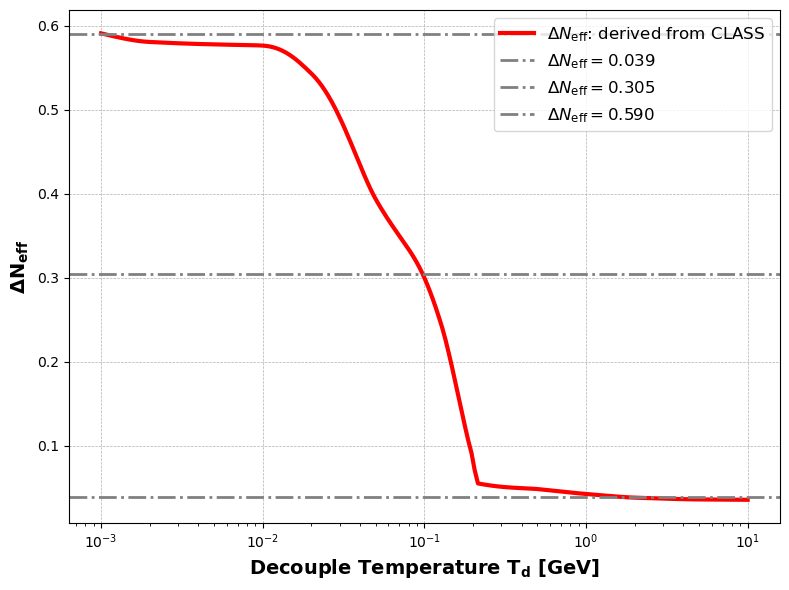

In [12]:
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8,6))

# Data
ax.plot(axion_temperature, deltaNeff_list, color='r', lw=3, label=r'$\Delta N_{\rm{eff}}$: derived from CLASS')
ax.axhline(0.039, color='gray', linestyle='-.', lw=2, label=r'$\Delta N_{\rm{eff}} = 0.039$')
ax.axhline(0.305, color='gray', linestyle='-.', lw=2, label=r'$\Delta N_{\rm{eff}} = 0.305$')
ax.axhline(0.590, color='gray', linestyle='-.', lw=2, label=r'$\Delta N_{\rm{eff}} = 0.590$')

# labels
ax.set_xscale('log')
ax.set_xlabel(r'Decouple Temperature $\bf T_d$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
# axs.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()